In [22]:
import pandas as pd
from os import listdir
from os.path import isfile, join
import numpy as np

In [23]:
def get_abs(abs_df, plate_template, absorbance, line):
    '''
    Function to extract the particular absorbance of a certain cell line and return that as a list
    
    Variables:
        abs_df = the pandas dataframe that contains the absorbances of all cell lines
        plate_template = the positioning of the lines on each of the cell plates
        absorbance = well...pretty self explainatory 
        line = cell line that you're intersted in 
    '''
    
    #first reformat the last column of the spreadsheet to only contain the absorbance as a number
    abs_df["Unnamed: 14"] = pd.to_numeric(abs_df["Unnamed: 14"].replace("Read [123]:", "", regex = True))
    #Filter by absorbance
    filtered_df = abs_df.loc[abs_df["Unnamed: 14"] == absorbance].reset_index(drop=True)
    #Filter by line
    values = filtered_df.where(plate_template == line).apply(lambda x: x.dropna().to_list())
    #Filter to only get lists with items 
    if isinstance(values, pd.DataFrame):
        return [0,0,0,0,0,0,0,0]
    
    else:
        abs_list = values[values.str.len() > 0].to_list()
        #Flatten the list (i.e. condense it to 1 list)
        abs_list = sum(abs_list, [])
        return np.array(abs_list)

In [24]:
cell_lines = [3059, 1691, 1690, 2342, 4532, 2344, 2343, 1952, 2931, "JG5", "BMS"] #2932
abs_lst = [650,680,750]
temperature = [25, 35, 16]

#Get the positions of the lines on their plates
plate_template = pd.read_excel("Plate_template.xlsx", sheet_name = 0)

In [25]:
absorbance_dict = {}
temp_data = [56,131,206]# Line numbers of where the temperature data starts
#go through the excel files in the cwd
for f in listdir("./"):
    if f == "Plate_template.xlsx":
        continue
    print(f)
    f_name = f.strip().split(".")
    #only look at files that end in an xl format
    if isfile(join("./", f)) and (f_name[-1][:2] == "xl"):
        for index in [0,1,2]: 
            #go through every plate layout in the file (0 = 25°C, 1 = 30°C, 2 = 35°C)
            abs_df = pd.read_excel(f, usecols = "B:O", skiprows = temp_data[index], nrows = 72)
            for line in cell_lines:
                for absorb in abs_lst:
                    key = "{abso}_{temp}_{cell_line}".format(abso = absorb, temp = temperature[index], cell_line = line)
                    abs_data = get_abs(abs_df, plate_template, absorb, line)
                    if len(abs_data) >= 8:
                        absorbance_dict[f_name[0]+"_"+key] = list(abs_data)
                        if len(abs_data) != 8:
                            print(key)

20230710-9AM.xls
20230703-1pm.xls
20230707-9PM.xls
20230703-3pm.xls
.DS_Store
Spec_Script_35_16.ipynb
20230706-9PM.xls
20230704-9PM.xls
20230705-9PM.xls
20230704-3PM.xls
20230707-9AM.xls
20230706-9AM.xls
20230705-3PM.xls
.ipynb_checkpoints
20230703-9pm.xls
20230704-9AM.xls
20230709-8PM.xls
20230707-3pm.xls
20230708-8PM.xls
20230706-3PM.xls
20230705-9AM.xls


In [18]:
len(absorbance_dict["20230703-9pm_680_25_2344"])

8

In [26]:
data_sorted = pd.DataFrame(absorbance_dict)

data_sorted.shape
data_sorted["Replicate"] = data_sorted.index
print(data_sorted.shape)
data_sorted

(8, 1783)


,20230710-9AM_650_25_3059,20230710-9AM_680_25_3059,20230710-9AM_750_25_3059,20230710-9AM_650_25_1691,20230710-9AM_680_25_1691,20230710-9AM_750_25_1691,20230710-9AM_650_25_1690,20230710-9AM_680_25_1690,20230710-9AM_750_25_1690,20230710-9AM_650_25_2342,...,20230705-9AM_650_16_2931,20230705-9AM_680_16_2931,20230705-9AM_750_16_2931,20230705-9AM_650_16_JG5,20230705-9AM_680_16_JG5,20230705-9AM_750_16_JG5,20230705-9AM_650_16_BMS,20230705-9AM_680_16_BMS,20230705-9AM_750_16_BMS,Replicate
0,1.642,2.091,1.147,1.944,2.293,1.253,1.188,1.366,1.021,1.135,...,0.205,0.231,0.171,0.051,0.052,0.053,0.195,0.237,0.159,0
1,2.299,2.771,1.370,1.503,1.802,1.063,0.826,0.856,0.686,1.676,...,0.191,0.219,0.157,0.116,0.127,0.108,0.221,0.274,0.177,1
2,1.621,2.057,1.142,1.581,1.946,1.025,0.439,0.533,0.447,1.119,...,0.179,0.206,0.149,0.054,0.055,0.054,0.214,0.270,0.170,2
3,1.679,2.126,1.171,1.475,1.900,1.119,0.636,0.731,0.508,1.221,...,0.156,0.178,0.135,0.071,0.075,0.070,0.160,0.191,0.135,3
4,1.573,1.989,1.099,1.697,2.039,1.183,0.617,0.621,0.539,1.383,...,0.151,0.170,0.131,0.069,0.071,0.069,0.191,0.242,0.150,4
5,1.712,2.164,1.190,2.151,2.704,1.217,1.329,1.333,0.967,1.238,...,0.150,0.167,0.133,0.056,0.057,0.058,0.216,0.264,0.176,5
6,1.577,1.920,1.184,1.652,1.981,1.148,2.023,2.358,1.401,1.219,...,0.208,0.242,0.168,0.080,0.085,0.077,0.197,0.245,0.159,6
7,1.563,1.948,1.105,1.592,1.841,1.137,1.203,1.351,0.969,1.187,...,0.128,0.139,0.114,0.134,0.149,0.121,0.206,0.251,0.167,7


In [27]:
data_sorted = data_sorted.melt(id_vars = ["Replicate"])
print(data_sorted.shape)
data_sorted["ID"] = data_sorted["variable"].astype("str") + "_"+ data_sorted["Replicate"].astype("str")
data_sorted = data_sorted[["ID","value"]]

(14256, 3)


In [28]:
#Reformat the dataframe
from datetime import datetime

data_sorted[['Hours', 'Absorbance', 'Temperature', 'Cell_Line', 'Replicate']] = data_sorted.ID.str.split("_", expand = True)
data_sorted[['Absorbance', 'Temperature', 'Replicate']] = data_sorted[['Absorbance', 'Temperature', 'Replicate']].apply(pd.to_numeric, errors='coerce', axis=1)
# data_sorted[["Cell_Line"]] = data_sorted[["Cell_Line"]].astype(int)

#Reformat the time and date column
data_sorted[["Hours"]] = data_sorted[["Hours"]].replace("am", "AM", regex=True)
data_sorted[["Hours"]] = data_sorted[["Hours"]].replace("pm", "PM", regex=True)
data_sorted["Hours"]  = pd.to_datetime(data_sorted["Hours"], format='%Y%m%d-%I%p')
data_sorted["Hours"] = (data_sorted["Hours"] - min(data_sorted["Hours"]))/np.timedelta64(1, 'h')

#ln transfomring the data
data_sorted["log10_transformed"] = pd.to_numeric(np.log10(data_sorted["value"]))


data_sorted.shape

(14256, 8)

In [29]:
data_sorted.to_csv("../../Cleaned_Data/25_35_16.csv")
data_sorted.head()
pd.unique(data_sorted.Cell_Line)

array(['3059', '1691', '1690', '2342', '4532', '2344', '2343', '1952',
       '2931', 'JG5', 'BMS'], dtype=object)

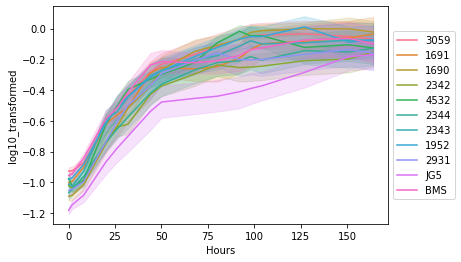

In [107]:
import seaborn as sns

plt = sns.lineplot(data = data_sorted, x = "Hours", y = "log10_transformed", hue = "Cell_Line")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

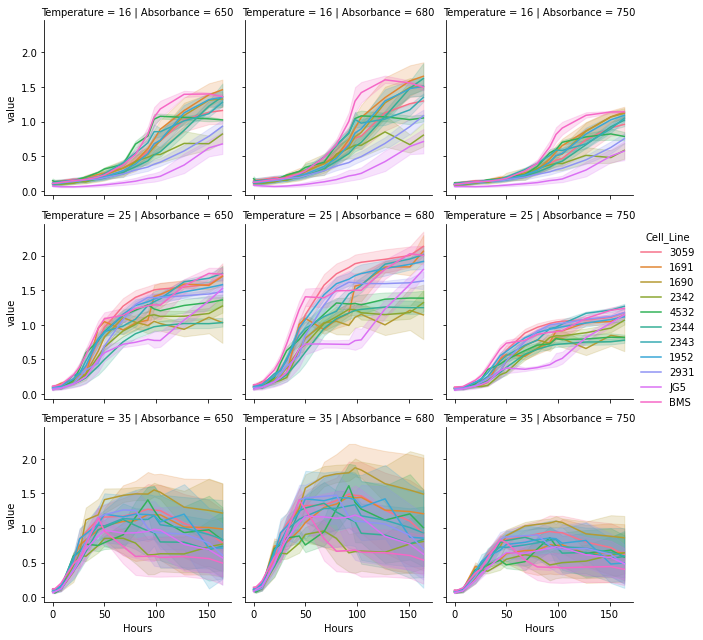

In [108]:
g = sns.FacetGrid(data_sorted, row="Temperature", col = "Absorbance", hue = "Cell_Line")
g.map(sns.lineplot,"Hours", "value")
g.add_legend()

In [109]:
data_sorted

,ID,value,Hours,Absorbance,Temperature,Cell_Line,Replicate,log10_transformed
0,20230710-9AM_650_25_3059_0,1.642,164.0,650,25,3059,0,0.215373
1,20230710-9AM_650_25_3059_1,2.299,164.0,650,25,3059,1,0.361539
2,20230710-9AM_650_25_3059_2,1.621,164.0,650,25,3059,2,0.209783
3,20230710-9AM_650_25_3059_3,1.679,164.0,650,25,3059,3,0.225051
4,20230710-9AM_650_25_3059_4,1.573,164.0,650,25,3059,4,0.196729
...,...,...,...,...,...,...,...,...
12667,20230705-9AM_750_16_BMS_3,0.135,44.0,750,16,BMS,3,-0.869666
12668,20230705-9AM_750_16_BMS_4,0.150,44.0,750,16,BMS,4,-0.823909
12669,20230705-9AM_750_16_BMS_5,0.176,44.0,750,16,BMS,5,-0.754487
12670,20230705-9AM_750_16_BMS_6,0.159,44.0,750,16,BMS,6,-0.798603


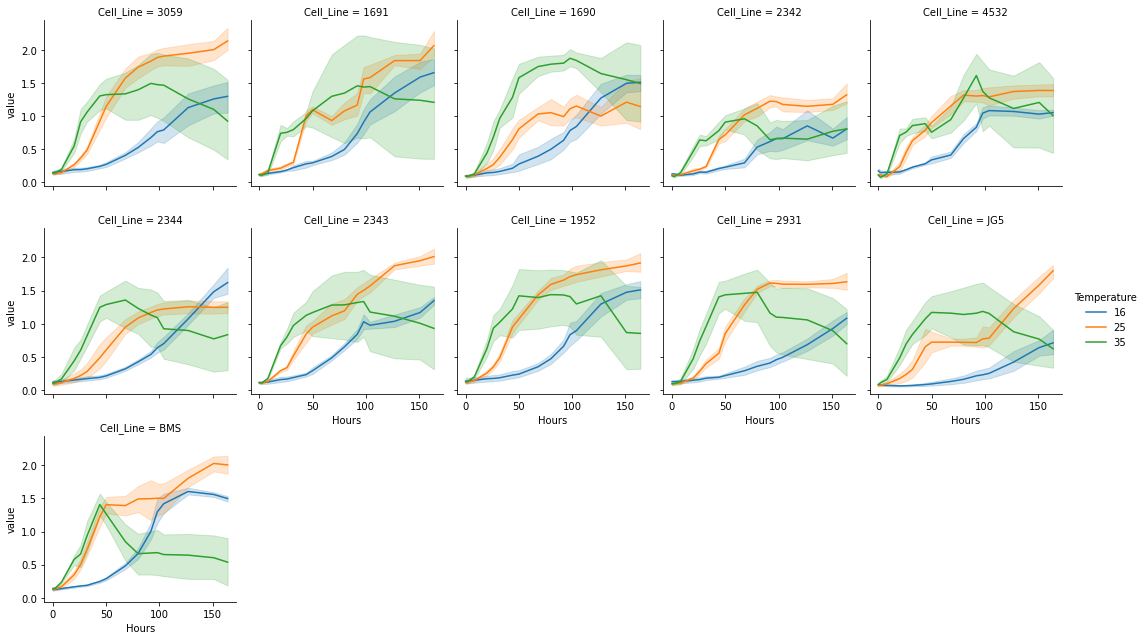

In [126]:
g = sns.FacetGrid(data_sorted[(data_sorted["Absorbance"] == 680)], col = "Cell_Line", col_wrap = 5, hue = "Temperature")
g.map(sns.lineplot,"Hours", "value")
g.add_legend()

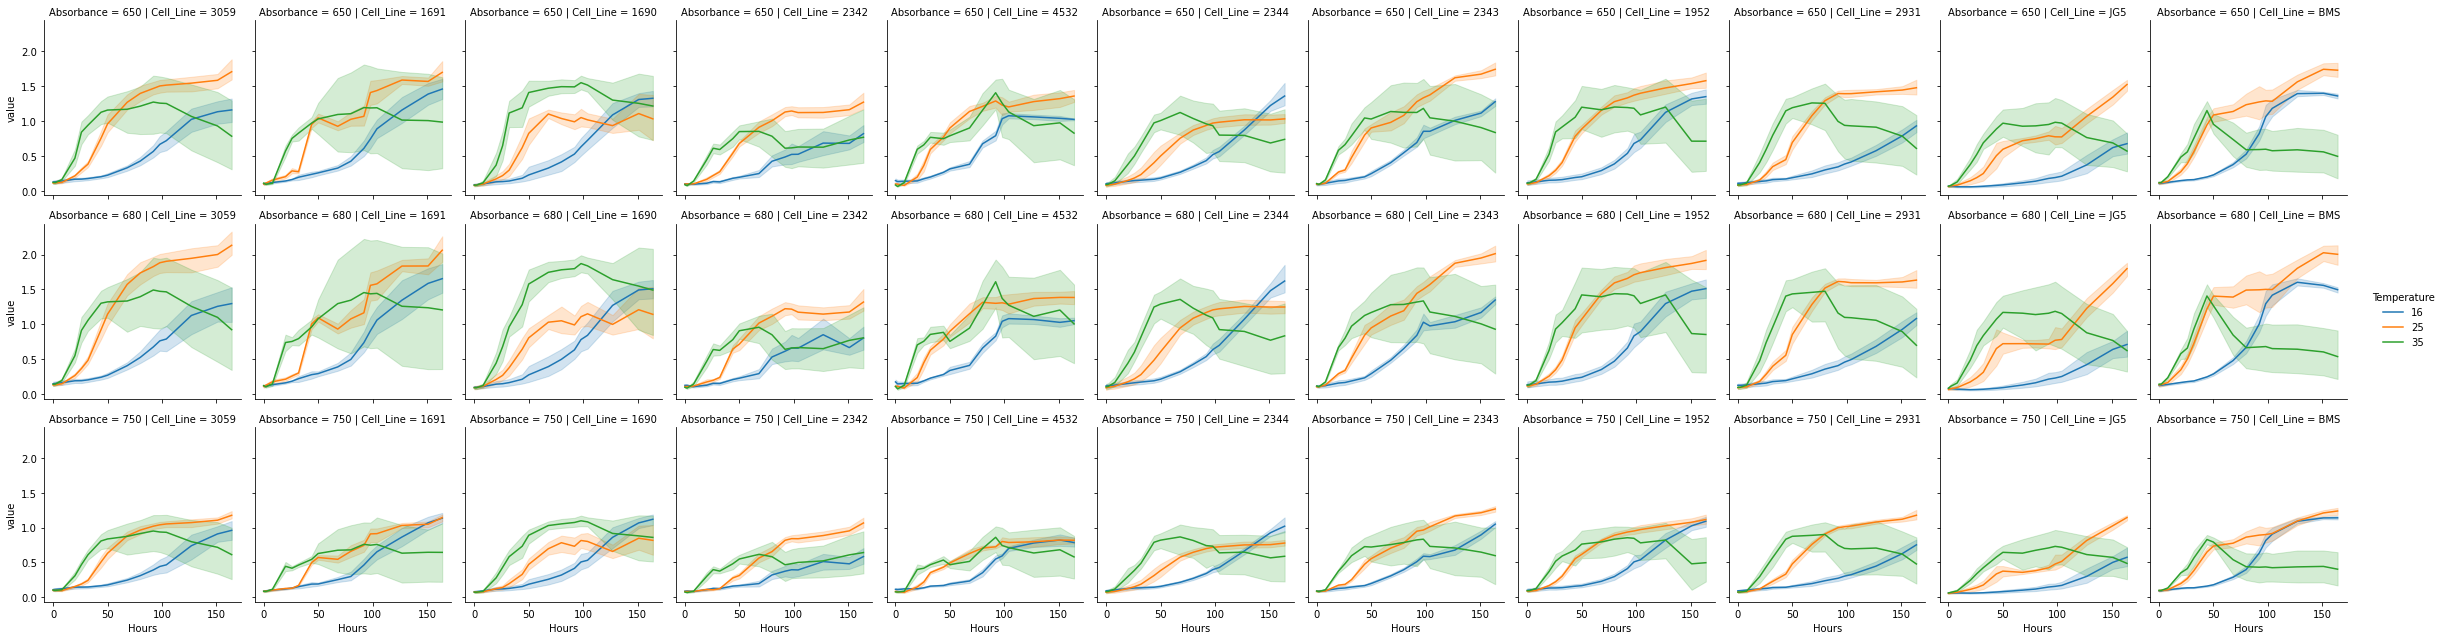

In [111]:
g = sns.FacetGrid(data_sorted, col="Cell_Line", row = "Absorbance", hue = "Temperature")
g.map(sns.lineplot,"Hours", "value")
g.add_legend()